### ライブラリ

In [1]:
import numpy as np

import plotly.graph_objects as go
from dataclasses import dataclass

### クラスの作成

In [2]:
@dataclass
class Node:
    num: int
    x :float
    y :float

In [3]:
class Element:

    def __init__(self, num: int, node1: Node, node2: Node, node3: Node):
        self.num = num
        self.node1 = node1
        self.node2 = node2
        self.node3 = node3
        self.node_nums = [node1.num, node2.num, node3.num] 
        self.B_matrix = self.calculate_B_matrix()
        self.D_matrix = self.set_D_matrix()
        self.K_matrix = self.calculate_K_matrix()
        self.Kw_matrix = self.calculate_Kw_matrix()
        

    def calculate_B_matrix(self):
        B_matrix = np.zeros((3,6))
        B_matrix[0][0] = self.node2.y - self.node3.y                    
        B_matrix[0][2] = self.node3.y - self.node1.y                    
        B_matrix[0][4] = self.node1.y - self.node2.y                    
        B_matrix[1][1] = self.node3.x - self.node2.x                    
        B_matrix[1][3] = self.node1.x - self.node3.x                    
        B_matrix[1][5] = self.node2.x - self.node1.x                    
        B_matrix[2][0] = self.node3.x - self.node2.x                    
        B_matrix[2][1] = self.node2.y - self.node3.y                    
        B_matrix[2][2] = self.node1.x - self.node3.x                    
        B_matrix[2][3] = self.node3.y - self.node1.y                    
        B_matrix[2][4] = self.node2.x - self.node1.x                    
        B_matrix[2][5] = self.node1.y - self.node2.y
        return B_matrix

    def set_D_matrix(self):
        return np.array(
            [[1.0, 0.5, 0.0],
             [0.5, 1.0, 0.0],
             [0.0, 0.0, 1.0]]
        )

    def calculate_K_matrix(self):
        return self.B_matrix.T @ self.D_matrix.T @ self.B_matrix

    def calculate_Kw_matrix(self):
        Kw_matrix = np.zeros((12,12))
        for i in range(6):
            idx_i = self.node_nums[int(i/2)]
            k = (idx_i - 1) * 2 +(i % 2)
            for j in range(6):
                idx_j = self.node_nums[int(j/2)]
                l = (idx_j - 1) * 2 +(j % 2)
                Kw_matrix[k][l] = self.K_matrix[i][j]
        return Kw_matrix

### インスタンスの作成

In [4]:
n1 = Node(1, 0.0, 0.0)
n2 = Node(2, 1.0, 0.0)
n3 = Node(3, 2.0, 0.0)
n4 = Node(4, 2.0, 1.0)
n5 = Node(5, 1.0, 1.0)
n6 = Node(6, 0.0, 1.0)

In [5]:
element1 = Element(1, n1, n2, n5)
element2 = Element(2, n2, n3, n4)
element3 = Element(3, n2, n4, n5)
element4 = Element(4, n1, n5, n6)

## 大域剛性行列の作成

In [6]:
K_whole = element1.Kw_matrix + element2.Kw_matrix + element3.Kw_matrix + element4.Kw_matrix
K_part = K_whole[2:10, 2:10]

## 荷重ベクトルの作成

In [7]:
f = np.zeros((4*2, 1))
f[5] = 0.075
f.shape

(8, 1)

## 変位ベクトルの計算

In [8]:
u = np.linalg.inv(K_part) @ f
u

array([[ 0.07767062],
       [ 0.12373887],
       [ 0.0865727 ],
       [ 0.28041543],
       [-0.05675074],
       [ 0.28931751],
       [-0.06053412],
       [ 0.08946588]])

## 荷重を加えた後の座標を求める

In [9]:
o1 = Node(1, 0.0, 0.0)
o2 = Node(2, 1.0+u[0][0], 0.0+u[1][0])
o3 = Node(3, 2.0+u[2][0], 0.0+u[3][0])
o4 = Node(4, 2.0+u[4][0], 1.0+u[5][0])
o5 = Node(5, 1.0+u[6][0], 1.0+u[7][0])
o6 = Node(6, 0.0, 1.0)

In [10]:
element10 = Element(1, o1, o2, o5)
element20 = Element(2, o2, o3, o4)
element30 = Element(3, o2, o4, o5)
element40 = Element(4, o1, o5, o6)

## 可視化

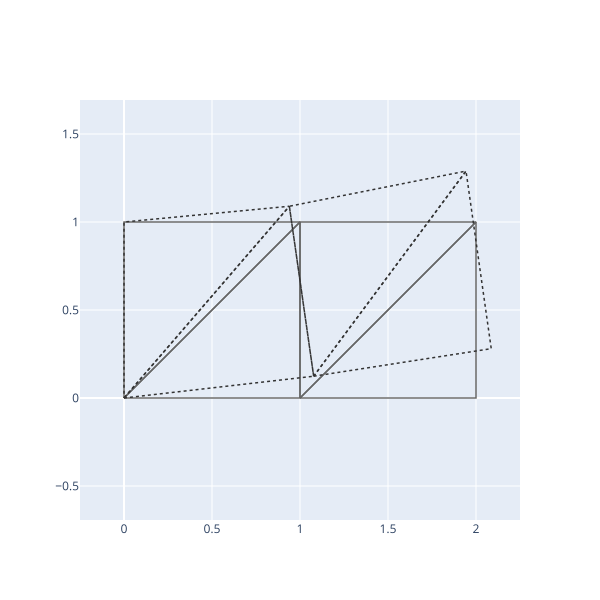

In [21]:
fig = go.Figure()
line_width = 1.5
fig.add_traces([
    go.Scatter(
        x=[element1.node1.x, element1.node2.x, element1.node3.x, element1.node1.x],
        y=[element1.node1.y, element1.node2.y, element1.node3.y, element1.node1.y],
        showlegend=False,
        name="element1",
        mode="lines",          # 線だけ描画
        line=dict(color="#666", width=line_width)
    ),
    go.Scatter(
        x=[element2.node1.x, element2.node2.x, element2.node3.x, element2.node1.x],
        y=[element2.node1.y, element2.node2.y, element2.node3.y, element2.node1.y],
        showlegend=False,
        name="element2",
        mode="lines",
        line=dict(color="#666", width=line_width)
    ),
    go.Scatter(
        x=[element3.node1.x, element3.node2.x, element3.node3.x, element3.node1.x],
        y=[element3.node1.y, element3.node2.y, element3.node3.y, element3.node1.y],
        showlegend=False,
        name="element3",
        mode="lines",
        line=dict(color="#666", width=line_width)
    ),
    go.Scatter(
        x=[element4.node1.x, element4.node2.x, element4.node3.x, element4.node1.x],
        y=[element4.node1.y, element4.node2.y, element4.node3.y, element4.node1.y],
        showlegend=False,
        name="element4",
        mode="lines",
        line=dict(color="#666", width=line_width)
    ),
        go.Scatter(
        x=[element10.node1.x, element10.node2.x, element10.node3.x, element10.node1.x],
        y=[element10.node1.y, element10.node2.y, element10.node3.y, element10.node1.y],
        showlegend=False,
        name="element1",
        mode="lines",          # 線だけ描画
        line=dict(color="#333", width=line_width, dash="dot")
    ),
    go.Scatter(
        x=[element20.node1.x, element20.node2.x, element20.node3.x, element20.node1.x],
        y=[element20.node1.y, element20.node2.y, element20.node3.y, element20.node1.y],
        showlegend=False,
        name="element2",
        mode="lines",
        line=dict(color="#333", width=line_width, dash="dot")
    ),
    go.Scatter(
        x=[element30.node1.x, element30.node2.x, element30.node3.x, element30.node1.x],
        y=[element30.node1.y, element30.node2.y, element30.node3.y, element30.node1.y],
        showlegend=False,
        name="element3",
        mode="lines",
        line=dict(color="#333", width=line_width, dash="dot")
    ),
    go.Scatter(
        x=[element40.node1.x, element40.node2.x, element40.node3.x, element40.node1.x],
        y=[element40.node1.y, element40.node2.y, element40.node3.y, element40.node1.y],
        showlegend=False,
        name="element4",
        mode="lines",
        line=dict(color="#333", width=line_width, dash="dot")
    ),
])
fig.update_xaxes(range=(-0.25,2.25))

fig.update_yaxes(
    scaleanchor="x",  # x 軸に基づいて縦横比固定
    scaleratio=1      # 1:1
)
fig.update_yaxes(range=(-0.25,1.25))
fig.update_layout(
    width=600,   # 図の外見の幅/高さ（任意）
    height=600
)
fig.show(renderer="svg")
# fig.show()